# Newline prediction frequency after attention-head ablation

For each attention head, this notebook independently replaces that head's `hook_z` output with its calibration mean (or zero), then measures how often the ablated model predicts `_NEWLINE_` at each value of **characters remaining**.

Characters remaining is the sampled line width minus the cumulative character count through the current input token. The reported frequency is `newline predictions / all evaluated positions` within each characters-remaining group. All heads use the same deterministic evaluation examples.

In [8]:
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

import project_main.checkpoints as project_checkpoints
import project_main.data as project_data
import project_main.model as project_model
import project_main.tokens as project_tokens

RUN_DIR = Path("../results/line_breaks_results")
CHECKPOINT_PATH = RUN_DIR / "checkpoints" / "final.pt"
ABLATION_TYPE = "mean"  # "mean" or "zero"
N_MEAN_SEQUENCES = 2_048
N_EVAL_SEQUENCES = 1_024
BATCH_SIZE = 128
MEAN_DATA_SEED = 17_001
EVAL_DATA_SEED = 17_002
N_PLOT_COLUMNS = 4


In [9]:
with open(RUN_DIR / "config.json", "r") as f:
    cfg = json.load(f)

device = "cuda" if torch.cuda.is_available() else "cpu"
vocab = project_tokens.build_vocab(cfg["task"])
model = project_model.build_model(cfg=cfg, device=device)
checkpoint = project_checkpoints.load_checkpoint(
    path=CHECKPOINT_PATH, model=model, map_location=device
)
model.eval()

n_layers = cfg["model"]["n_layers"]
n_heads = cfg["model"]["n_heads"]
d_head = cfg["model"]["d_head"]
z_names = [f"blocks.{layer}.attn.hook_z" for layer in range(n_layers)]
min_width, max_width = project_data.get_line_length_range(cfg["task"])
max_token_length = cfg["task"]["num_token_lengths"]
remaining_values = np.arange(-(max_token_length - 1), max_width + 1)

if ABLATION_TYPE not in {"mean", "zero"}:
    raise ValueError("ABLATION_TYPE must be either 'mean' or 'zero'.")
print(f"Loaded checkpoint step {checkpoint['step']} on {device}")
print(f"Model: {n_layers} layers x {n_heads} heads")
print(f"Characters-remaining range: {remaining_values.min()} through {remaining_values.max()}")


Building vocab...
('BOS', '_NEWLINE_')
Loaded checkpoint step 10000 on cpu
Model: 3 layers x 4 heads
Characters-remaining range: -7 through 100


## Construct replacement vectors

In [10]:
@torch.no_grad()
def estimate_all_head_means(n_sequences, batch_size=BATCH_SIZE, seed=MEAN_DATA_SEED):
    head_sums = torch.zeros(n_layers, n_heads, d_head, dtype=torch.float64)
    n_vectors = 0
    for start in range(0, n_sequences, batch_size):
        size = min(batch_size, n_sequences - start)
        batch = project_data.make_batch(size, vocab, cfg["task"], device, seed + start)
        _, cache = model.run_with_cache(batch.tokens, prepend_bos=False,
            names_filter=lambda name: name in z_names)
        for layer, name in enumerate(z_names):
            head_sums[layer] += cache[name].detach().cpu().double().sum(dim=(0, 1))
        n_vectors += size * cfg["task"]["seq_len"]
    return (head_sums / n_vectors).float()

replacement_head_outputs = (
    estimate_all_head_means(N_MEAN_SEQUENCES)
    if ABLATION_TYPE == "mean"
    else torch.zeros(n_layers, n_heads, d_head)
)


## Evaluate newline frequency by characters remaining

In [11]:
def characters_remaining(token_rows, line_widths):
    """Return one signed remaining-character value for every input position."""
    values = []
    for row, width in zip(token_rows.detach().cpu().tolist(), line_widths.detach().cpu().tolist()):
        count = 0
        row_values = []
        for token_id in row:
            token_name = vocab.decode_token(token_id)
            if token_id == vocab.newline_id:
                count = 0
            else:
                count += project_data.extract_character_count(token_name)
            row_values.append(width - count)
        values.append(row_values)
    return torch.tensor(values, dtype=torch.long)

@torch.no_grad()
def evaluate_frequency(ablate_layer=None, ablate_head=None, *, n_sequences=N_EVAL_SEQUENCES,
                      batch_size=BATCH_SIZE, seed=EVAL_DATA_SEED):
    counts = np.zeros((len(remaining_values), 2), dtype=np.int64)  # predicted, total
    hooks = []
    if ablate_layer is not None:
        replacement = replacement_head_outputs[ablate_layer, ablate_head]
        def ablate(z, hook):
            out = z.clone()
            out[:, :, ablate_head, :] = replacement.to(device=z.device, dtype=z.dtype)
            return out
        hooks = [(z_names[ablate_layer], ablate)]
    for start in range(0, n_sequences, batch_size):
        size = min(batch_size, n_sequences - start)
        batch = project_data.make_batch(size, vocab, cfg["task"], device, seed + start)
        logits = model.run_with_hooks(batch.tokens, prepend_bos=False, fwd_hooks=hooks)
        predicted = (logits.argmax(dim=-1) == vocab.newline_id).cpu().numpy()
        remaining = characters_remaining(batch.tokens, batch.line_lengths).numpy()
        for i, value in enumerate(remaining_values):
            mask = remaining == value
            counts[i, 0] += predicted[mask].sum()
            counts[i, 1] += mask.sum()
    frequency = np.divide(counts[:, 0], counts[:, 1], out=np.full(len(counts), np.nan), where=counts[:, 1] > 0)
    return frequency, counts[:, 1]

baseline_frequency, sample_counts = evaluate_frequency()
records = []
for layer in range(n_layers):
    for head in range(n_heads):
        frequency, counts = evaluate_frequency(layer, head)
        for value, freq, n in zip(remaining_values, frequency, counts):
            records.append({"layer": layer, "head": head, "characters_remaining": value,
                            "newline_prediction_frequency": freq, "sample_count": n})
        print(f"L{layer}H{head}: mean frequency={np.nanmean(frequency):.4f}")
results = pd.DataFrame(records)


L0H0: mean frequency=0.8224
L0H1: mean frequency=0.0844
L0H2: mean frequency=0.0895
L0H3: mean frequency=0.0394
L1H0: mean frequency=0.1110
L1H1: mean frequency=0.0214
L1H2: mean frequency=0.1108
L1H3: mean frequency=0.0774
L2H0: mean frequency=0.1128
L2H1: mean frequency=0.1333
L2H2: mean frequency=0.1100
L2H3: mean frequency=0.0938


## Frequency table

In [12]:
display(results.head(20).style.format({
    "newline_prediction_frequency": "{:.4f}"
}))

# Wide form is convenient for exporting or inspecting exact grouped values.
frequency_table = results.pivot_table(index="characters_remaining", columns=["layer", "head"], values="newline_prediction_frequency")
display(frequency_table.style.format("{:.4f}"))


,layer,head,characters_remaining,newline_prediction_frequency,sample_count
0,0,0,-7,1.0000,223
1,0,0,-6,1.0000,466
2,0,0,-5,1.0000,708
3,0,0,-4,1.0000,918
4,0,0,-3,1.0000,1195
5,0,0,-2,1.0000,1315
6,0,0,-1,1.0000,1611
7,0,0,0,1.0000,1808
8,0,0,1,1.0000,1801
9,0,0,2,1.0000,1941


## Curves for every ablated head

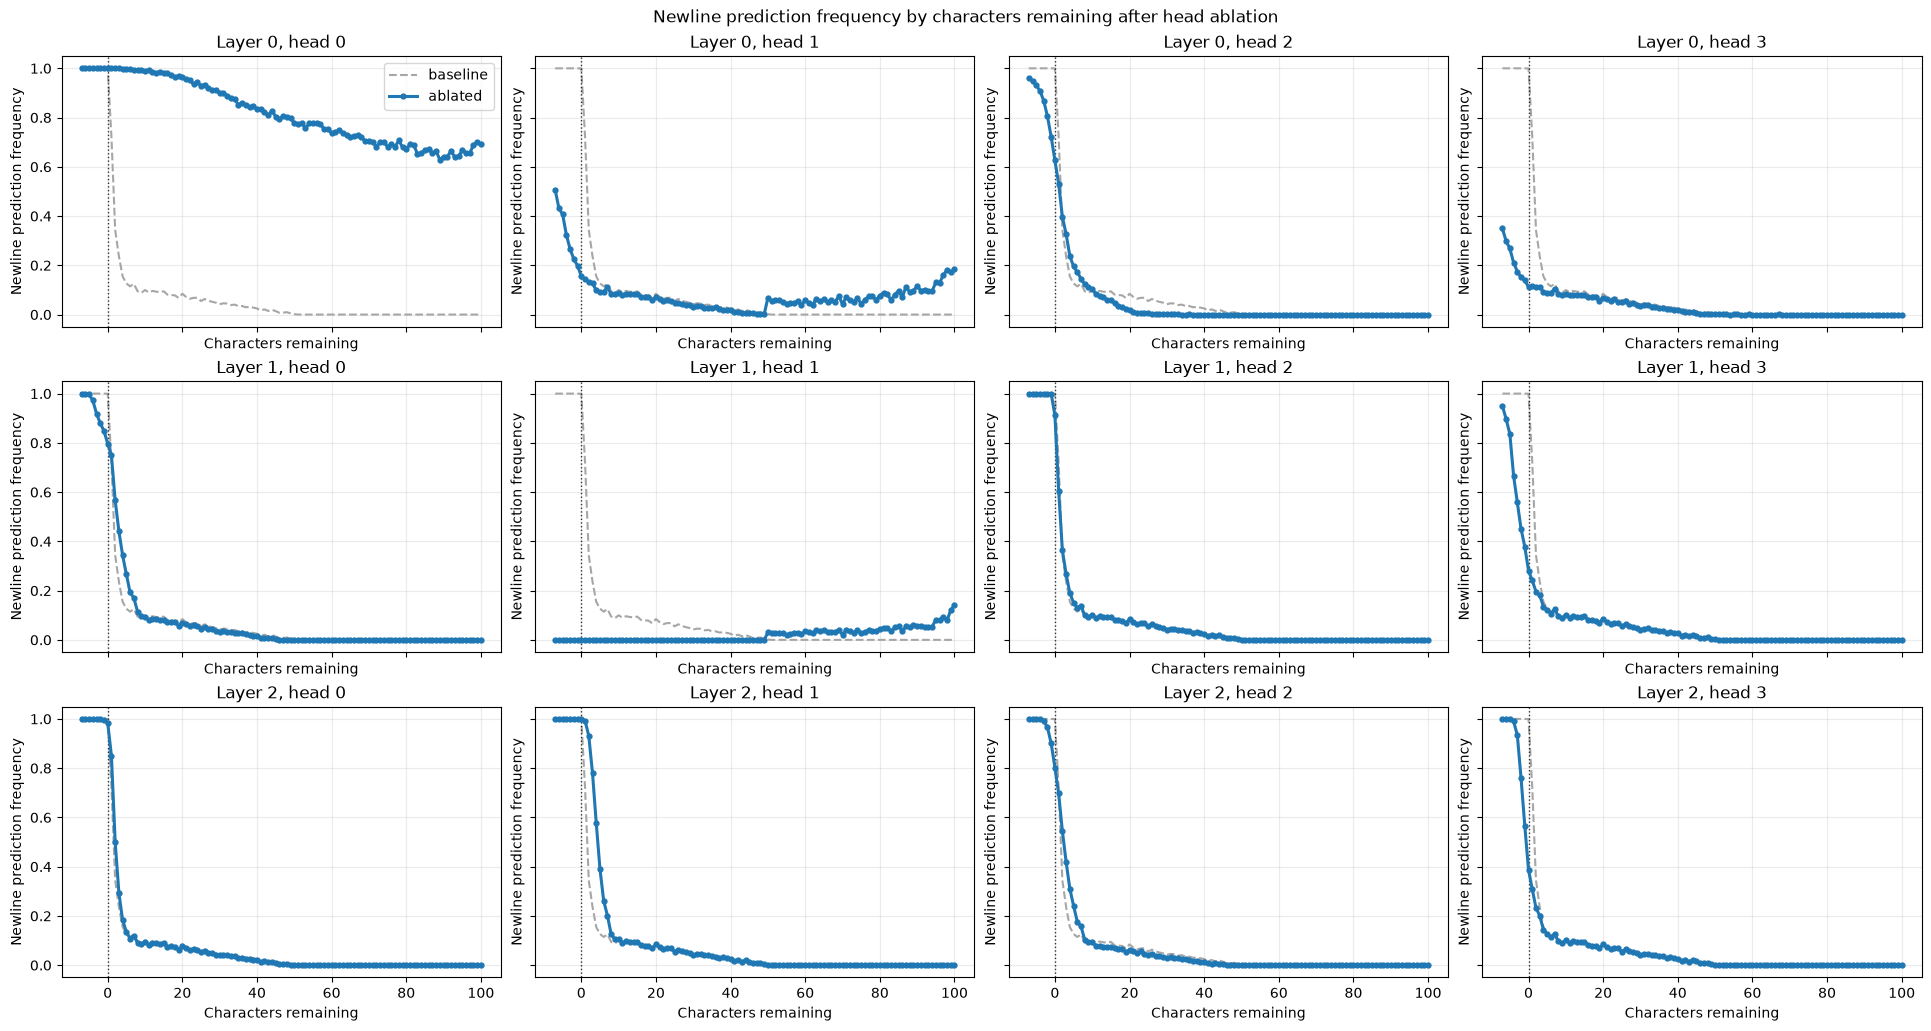

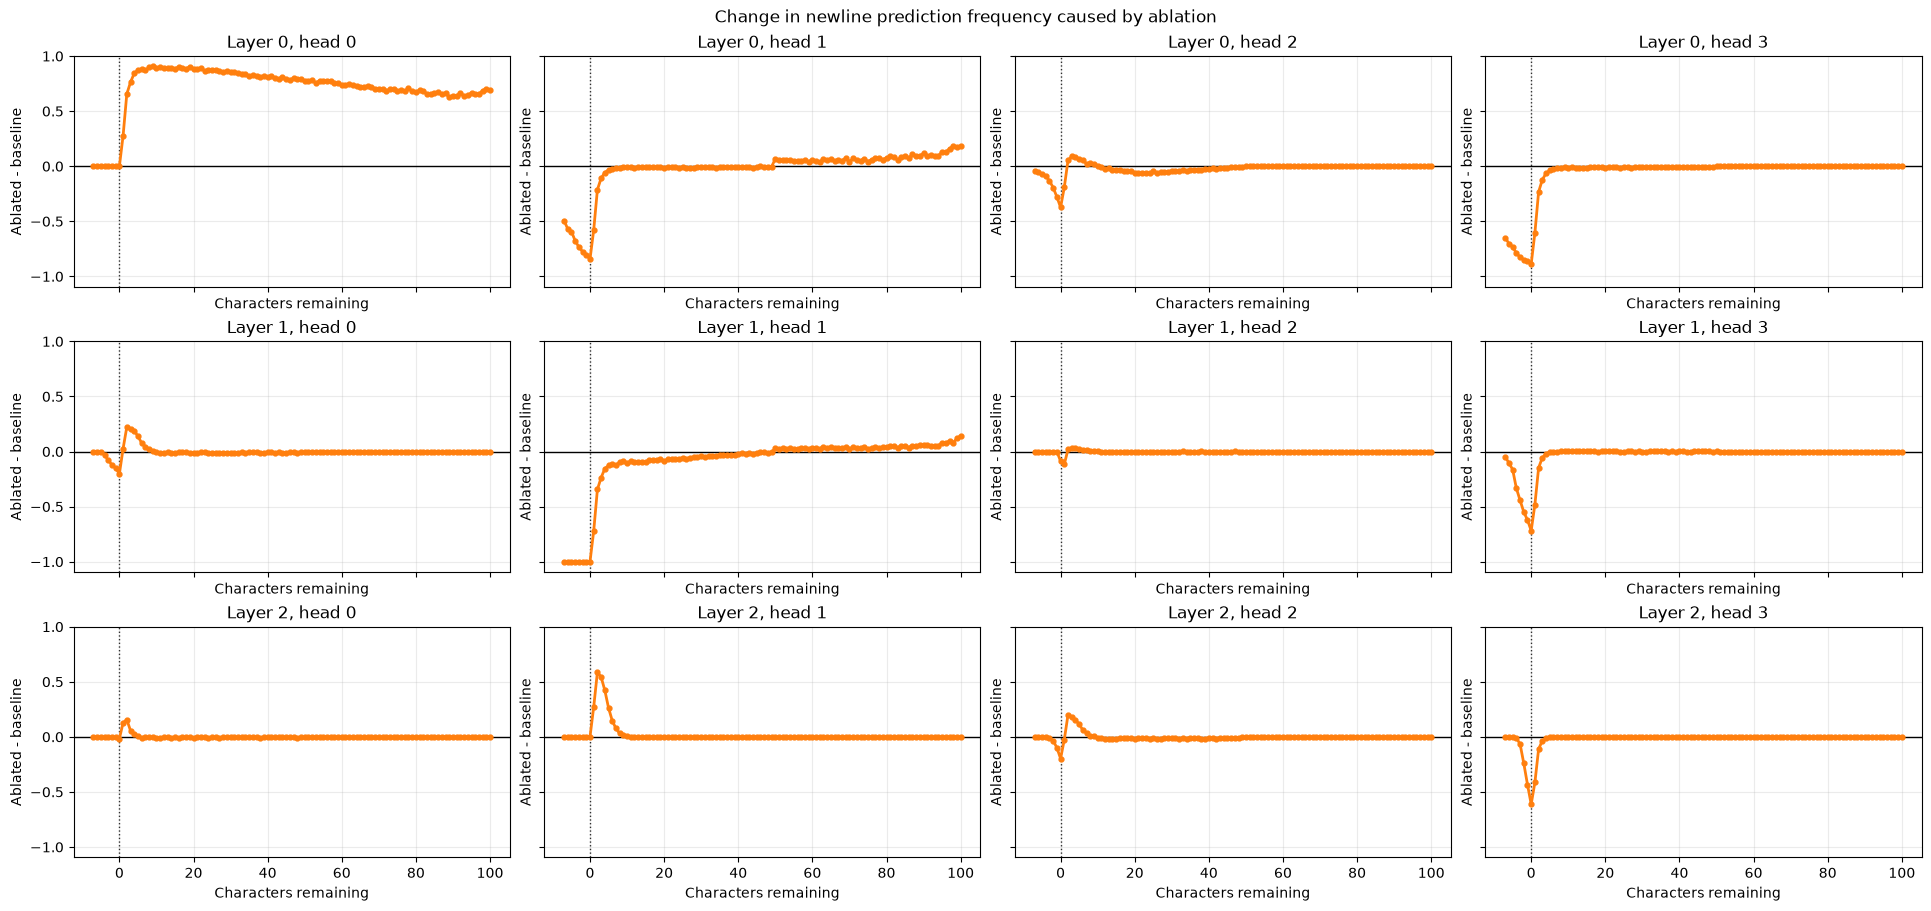

In [13]:
n_panels = n_layers * n_heads
n_columns = min(N_PLOT_COLUMNS, n_panels)
n_rows = math.ceil(n_panels / n_columns)
fig, axes = plt.subplots(n_rows, n_columns, figsize=(4.8*n_columns, 3.4*n_rows),
                         sharex=True, sharey=True, constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

# Use a distinct color/marker and higher z-order for the ablated curve so it
# remains visible even when it is close to the unablated baseline.
for panel, (layer, head) in enumerate((l, h) for l in range(n_layers) for h in range(n_heads)):
    ax = axes[panel]
    row = results[(results["layer"] == layer) & (results["head"] == head)].sort_values("characters_remaining")
    x = row["characters_remaining"].to_numpy()
    ablated = row["newline_prediction_frequency"].to_numpy()

    ax.plot(remaining_values, baseline_frequency, color="0.65", linestyle="--",
            linewidth=1.5, label="baseline", zorder=1)
    ax.plot(x, ablated, color="tab:blue", marker="o", markersize=3.5,
            linewidth=2.2, label="ablated", zorder=3)
    ax.axvline(0, color="black", linestyle=":", linewidth=1, alpha=0.8, zorder=2)
    ax.set_title(f"Layer {layer}, head {head}")
    ax.set_xlabel("Characters remaining")
    ax.set_ylabel("Newline prediction frequency")
    ax.grid(alpha=0.25)
    if panel == 0:
        ax.legend()

for ax in axes[n_panels:]:
    ax.remove()
fig.suptitle("Newline prediction frequency by characters remaining after head ablation")
plt.show()

# Difference plot: this directly shows the effect of each ablation, including
# cases where the two frequency curves are visually close.
fig, axes = plt.subplots(n_rows, n_columns, figsize=(4.8*n_columns, 3.0*n_rows),
                         sharex=True, sharey=True, constrained_layout=True)
axes = np.atleast_1d(axes).ravel()
for panel, (layer, head) in enumerate((l, h) for l in range(n_layers) for h in range(n_heads)):
    ax = axes[panel]
    row = results[(results["layer"] == layer) & (results["head"] == head)].sort_values("characters_remaining")
    difference = row["newline_prediction_frequency"].to_numpy() - baseline_frequency
    ax.axhline(0, color="black", linewidth=1)
    ax.plot(row["characters_remaining"], difference, color="tab:orange",
            marker="o", markersize=3.5, linewidth=2, zorder=3)
    ax.axvline(0, color="black", linestyle=":", linewidth=1, alpha=0.8)
    ax.set_title(f"Layer {layer}, head {head}")
    ax.set_xlabel("Characters remaining")
    ax.set_ylabel("Ablated - baseline")
    ax.grid(alpha=0.25)
for ax in axes[n_panels:]:
    ax.remove()
fig.suptitle("Change in newline prediction frequency caused by ablation")
plt.show()
